# RNN ki Limitations aur unka LSTM & GRU se Solution


Is notebook ka goal:

1. Time series data ko samajhna  
2. Simple RNN banana  
3. Isi dataset par RNN ki practical limitations dekhain gy
4. LSTM aur GRU se un limitations ko reduce kysy krain gy 
5. RNN, LSTM aur GRU ka fair comparison karin gy

> **Target:** Pichlay 30 din ki information use karke aglay din ki `Sales` predict karna.


In [1]:
# Required libraries import kar rahe hain.

import random

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt


from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score


import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input

from tensorflow.keras.layers import SimpleRNN

from tensorflow.keras.layers import LSTM

from tensorflow.keras.layers import GRU

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping


# Results ko repeatable banane ke liye random seeds set kar rahe hain.

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


## Step 1: Dataset Load 

CSV file aur notebook ko same folder mein rakhein.


In [2]:
data = pd.read_csv('timeseries.csv')
data


,Date,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales
0,2023-01-01,6,1,1,0,1,24.99,495,23.29,11959.39
1,2023-01-02,0,1,0,0,0,23.90,331,20.68,7130.94
2,2023-01-03,1,1,0,0,0,25.64,375,22.70,9575.30
3,2023-01-04,2,1,0,0,0,27.56,299,22.19,6239.60
4,2023-01-05,3,1,0,0,0,24.22,329,22.99,7922.72
...,...,...,...,...,...,...,...,...,...,...
725,2024-12-26,3,12,0,0,0,22.77,253,26.47,7310.56
726,2024-12-27,4,12,0,0,0,23.35,293,22.24,6285.46
727,2024-12-28,5,12,1,0,0,24.18,383,25.59,10523.98
728,2024-12-29,6,12,1,0,0,22.58,441,25.34,11719.07


In [3]:
# Dataset ka shape dekh rahe hain.

print("Rows aur Columns:", data.shape)


# Columns ke names dekh rahe hain.

print("\nColumn Names:")

print(data.columns.tolist())


Rows aur Columns: (730, 10)

Column Names:
['Date', 'Day_of_Week', 'Month', 'Weekend', 'Promotion', 'Holiday', 'Temperature', 'Visitors', 'Average_Order_Value', 'Sales']


In [4]:
# Data types aur missing values ki basic information dekh rahe hain.

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 730 non-null    object 
 1   Day_of_Week          730 non-null    int64  
 2   Month                730 non-null    int64  
 3   Weekend              730 non-null    int64  
 4   Promotion            730 non-null    int64  
 5   Holiday              730 non-null    int64  
 6   Temperature          730 non-null    float64
 7   Visitors             730 non-null    int64  
 8   Average_Order_Value  730 non-null    float64
 9   Sales                730 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 57.2+ KB


In [5]:
# Har column ke missing values count kar rahe hain.

data.isnull().sum()


Date                   0
Day_of_Week            0
Month                  0
Weekend                0
Promotion              0
Holiday                0
Temperature            0
Visitors               0
Average_Order_Value    0
Sales                  0
dtype: int64

## Step 2: Date ko Proper Format mein Convert Kar rhy h 

Time series mein date order bohat important hota hai.  
Hum data ko date ke mutabiq sort bhi karenge.


In [6]:
# Date column ko datetime format mein convert kar rahe hain.

data["Date"] = pd.to_datetime(data["Date"])


# Date ke mutabiq ascending order mein sort kar rahe hain.

data = data.sort_values("Date").reset_index(drop=True)


# Duplicate dates check kar rahe hain.

print("Duplicate Dates:", data["Date"].duplicated().sum())


data.head()


Duplicate Dates: 0


,Date,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales
0,2023-01-01,6,1,1,0,1,24.99,495,23.29,11959.39
1,2023-01-02,0,1,0,0,0,23.90,331,20.68,7130.94
2,2023-01-03,1,1,0,0,0,25.64,375,22.70,9575.30
3,2023-01-04,2,1,0,0,0,27.56,299,22.19,6239.60
4,2023-01-05,3,1,0,0,0,24.22,329,22.99,7922.72


In [7]:
data.Date.dt.year.unique()

array([2023, 2024], dtype=int32)

## Step 3: Easy Exploratory Data Analysis

Pehle sales ka overall trend dekhenge.


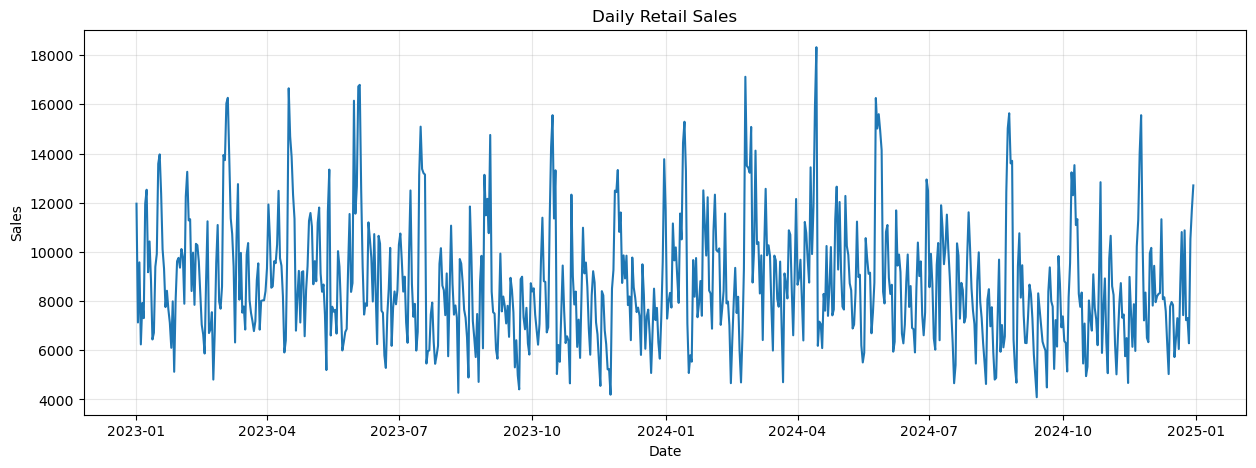

In [8]:
# Daily sales ka time-series graph bana rahe hain.

plt.figure(figsize=(15, 5))

plt.plot(data["Date"], data["Sales"])

plt.title("Daily Retail Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()


In [9]:
data

,Date,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales
0,2023-01-01,6,1,1,0,1,24.99,495,23.29,11959.39
1,2023-01-02,0,1,0,0,0,23.90,331,20.68,7130.94
2,2023-01-03,1,1,0,0,0,25.64,375,22.70,9575.30
3,2023-01-04,2,1,0,0,0,27.56,299,22.19,6239.60
4,2023-01-05,3,1,0,0,0,24.22,329,22.99,7922.72
...,...,...,...,...,...,...,...,...,...,...
725,2024-12-26,3,12,0,0,0,22.77,253,26.47,7310.56
726,2024-12-27,4,12,0,0,0,23.35,293,22.24,6285.46
727,2024-12-28,5,12,1,0,0,24.18,383,25.59,10523.98
728,2024-12-29,6,12,1,0,0,22.58,441,25.34,11719.07


In [10]:
# Weekend aur normal days ki average sales compare kar rahe hain.

weekend_sales = data.groupby("Weekend")["Sales"].mean()

print(weekend_sales)


Weekend
0     8054.448599
1    10437.810622
Name: Sales, dtype: float64


In [11]:
# Promotion aur non-promotion days ki average sales compare kar rahe hain.

promotion_sales = data.groupby("Promotion")["Sales"].mean()

print(promotion_sales)


Promotion
0     8177.108646
1    13284.369000
Name: Sales, dtype: float64


In [12]:
# Numerical columns ka correlation matrix dekh rahe hain.

correlation_matrix = data.select_dtypes(include=np.number).corr()

correlation_matrix.round(2)


,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales
Day_of_Week,1.00,0.01,0.79,-0.00,0.02,0.00,0.13,0.16,0.20
Month,0.01,1.00,0.01,-0.04,-0.01,-0.75,-0.31,-0.03,-0.21
Weekend,0.79,0.01,1.00,-0.01,0.07,0.00,0.44,0.22,0.44
Promotion,-0.00,-0.04,-0.01,1.00,-0.05,-0.00,0.56,0.40,0.65
Holiday,0.02,-0.01,0.07,-0.05,1.00,-0.01,0.18,0.01,0.15
Temperature,0.00,-0.75,0.00,-0.00,-0.01,1.00,0.36,-0.01,0.23
Visitors,0.13,-0.31,0.44,0.56,0.18,0.36,1.00,0.33,0.88
Average_Order_Value,0.16,-0.03,0.22,0.40,0.01,-0.01,0.33,1.00,0.67
Sales,0.20,-0.21,0.44,0.65,0.15,0.23,0.88,0.67,1.00


## Step 4: Date Feature Engineering

Raw `Date` ko neural network directly samajh nahi sakta.  
Is liye hum useful date features banayenge:

- Day of Week
- Month
- Day of Month

Dataset mein `Day_of_Week` aur `Month` pehle se hain. Hum `Day_of_Month` add karenge.


In [13]:
data.head(1)

,Date,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales
0,2023-01-01,6,1,1,0,1,24.99,495,23.29,11959.39


In [14]:
# Date se day of month create kar rahe hain.

data["Day_of_Month"] = data["Date"].dt.day


# Updated columns dekh rahe hain.

data.head()


,Date,Day_of_Week,Month,Weekend,Promotion,Holiday,Temperature,Visitors,Average_Order_Value,Sales,Day_of_Month
0,2023-01-01,6,1,1,0,1,24.99,495,23.29,11959.39,1
1,2023-01-02,0,1,0,0,0,23.90,331,20.68,7130.94,2
2,2023-01-03,1,1,0,0,0,25.64,375,22.70,9575.30,3
3,2023-01-04,2,1,0,0,0,27.56,299,22.19,6239.60,4
4,2023-01-05,3,1,0,0,0,24.22,329,22.99,7922.72,5


## Step 5: Features aur Target Select Kar rhy h

`Sales` ko input mein bhi rakha gaya hai, lekin current day ki sales nahi.

Har sample mein:

- Previous 30 days ki Sales aur doosray features input honge.
- Next day ki Sales target hogi.

Isay **autoregressive forecasting** kehte hain.


In [15]:
# Model ko diye jane wale input features define kar rahe hain.

feature_columns = [

    "Visitors",

    "Promotion",

    "Weekend",

    "Holiday",

    "Temperature",

    "Average_Order_Value",

    "Day_of_Week",

    "Month",

    "Day_of_Month",

    "Sales"

]


# Target column define kar rahe hain.

target_column = "Sales"


print("Features:", feature_columns)

print("Target:", target_column)


Features: ['Visitors', 'Promotion', 'Weekend', 'Holiday', 'Temperature', 'Average_Order_Value', 'Day_of_Week', 'Month', 'Day_of_Month', 'Sales']
Target: Sales


## Step 6: Time Based Train/Test Split

Time series data ko random shuffle nahi karna chahiye.

Hum:

- pehle 80% data training ke liye,
- aakhri 20% data testing ke liye

use karenge.


In [16]:
# Total observations count kar rahe hain.

total_rows = len(data)


# 80% split index calculate kar rahe hain.

train_end_index = int(total_rows * 0.80)


# Training aur testing raw data create kar rahe hain.

train_data = data.iloc[:train_end_index].copy()

test_data = data.iloc[train_end_index:].copy()


print("Training Rows:", len(train_data))

print("Testing Rows:", len(test_data))

print("Training End Date:", train_data["Date"].max())

print("Testing Start Date:", test_data["Date"].min())

print(train_end_index)

Training Rows: 584
Testing Rows: 146
Training End Date: 2024-08-06 00:00:00
Testing Start Date: 2024-08-07 00:00:00
584


In [17]:
584+146

730

## Step 7: Scaling Data Leakage ke baghair

Scaler ko sirf training data par `fit` karenge.

Agar poore dataset par scaler fit kar diya jaye to test-set ki information training process mein leak ho sakti hai.


In [18]:
# Features aur target ke liye separate scalers bana rahe hain.

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()


# Feature scaler ko sirf training features par fit kar rahe hain.

feature_scaler.fit(train_data[feature_columns])


# Target scaler ko sirf training target par fit kar rahe hain.

target_scaler.fit(train_data[[target_column]])


# Ab poore ordered dataset ko training-fitted scalers se transform kar rahe hain.

scaled_features = feature_scaler.transform(data[feature_columns])

scaled_target = target_scaler.transform(data[[target_column]])


print("Scaled Features Shape:", scaled_features.shape)

print("Scaled Target Shape:", scaled_target.shape)


Scaled Features Shape: (730, 10)
Scaled Target Shape: (730, 1)


## Step 8: Sequences Banana

`TIME_STEPS = 30` ka matlab:

- Previous 30 days input
- Day 31 ki Sales target

Long sequence Simple RNN ki memory limitation ko zyada clearly show kar sakti hai.


In [19]:
# Previous kitne days use karne hain.

TIME_STEPS = 30


# Sequence creation function bana rahe hain.

def create_sequences(features, target, time_steps):

    X = []

    y = []


    for index in range(time_steps, len(features)):

        previous_days = features[index - time_steps:index]

        next_day_sales = target[index]


        X.append(previous_days)

        y.append(next_day_sales)


    return np.array(X), np.array(y)


# Complete sequences create kar rahe hain.

X, y = create_sequences(

    scaled_features,

    scaled_target,

    TIME_STEPS

)


print("X Shape:", X.shape)

print("y Shape:", y.shape)


X Shape: (700, 30, 10)
y Shape: (700, 1)


In [26]:
# Sequence target ka original data index TIME_STEPS se start hota hai.

sequence_target_indices = np.arange(TIME_STEPS, len(data))


# Training targets woh hain jo original training range mein aate hain.

train_sequence_mask = sequence_target_indices < train_end_index


# Testing targets woh hain jo original test range mein aate hain.

test_sequence_mask = sequence_target_indices >= train_end_index


# Train aur test sequences separate kar rahe hain.

X_train = X[train_sequence_mask]

y_train = y[train_sequence_mask]


X_test = X[test_sequence_mask]

y_test = y[test_sequence_mask]


# Test dates save kar rahe hain.

test_dates = data.loc[sequence_target_indices[test_sequence_mask], "Date"].reset_index(drop=True)


print("X_train Shape:", X_train.shape)

print("y_train Shape:", y_train.shape)

print("X_test Shape:", X_test.shape)

print("y_test Shape:", y_test.shape)


X_train Shape: (554, 30, 10)
y_train Shape: (554, 1)
X_test Shape: (146, 30, 10)
y_test Shape: (146, 1)


In [27]:
test_dates

0     2024-08-07
1     2024-08-08
2     2024-08-09
3     2024-08-10
4     2024-08-11
         ...    
141   2024-12-26
142   2024-12-27
143   2024-12-28
144   2024-12-29
145   2024-12-30
Name: Date, Length: 146, dtype: datetime64[ns]

In [21]:
sequence_target_indices

array([ 30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
       173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,
       186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198,
       199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 21

# Part A Simple RNN

## Simple RNN kyun use kar rahe hain?

Simple RNN sequence ko step by step process karta hai aur hidden state mein previous information rakhta hai.

Lekin lambi sequence mein:

1. purani information lose ho sakti hai,
2. vanishing gradient problem aa sakti hai,
3. delayed promotion/holiday effects learn karna mushkil ho sakta hai.


In [28]:
# Simple RNN model function define kar rahe hain.

def build_rnn_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        SimpleRNN(

            units=32,

            activation="tanh"

        ),

        Dropout(0.20),

        Dense(

            units=16,

            activation="relu"

        ),

        Dense(

            units=1

        )

    ])


    model.compile(

        optimizer="adam",

        loss="mse",

        metrics=["mae"]

    )


    return model


In [32]:
X_train.shape[2]

10

In [33]:
# RNN model create kar rahe hain.

rnn_model = build_rnn_model(

    input_shape=(X_train.shape[1], X_train.shape[2])

)


# Model architecture display kar rahe hain.

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,921 (7.50 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Overfitting reduce karne ke liye EarlyStopping use kar rahe hain.

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)


# Simple RNN train kar rahe hain.

rnn_history = rnn_model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.20,

    callbacks=[early_stopping],

    shuffle=False,

    verbose=1

)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.1080 - mae: 0.2574 - val_loss: 0.0332 - val_mae: 0.1366
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0499 - mae: 0.1721 - val_loss: 0.0264 - val_mae: 0.1268
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0361 - mae: 0.1481 - val_loss: 0.0190 - val_mae: 0.1062
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0280 - mae: 0.1281 - val_loss: 0.0186 - val_mae: 0.0993
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0275 - mae: 0.1266 - val_loss: 0.0138 - val_mae: 0.0879
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0264 - mae: 0.1267 - val_loss: 0.0133 - val_mae: 0.0837
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0243 - mae: 0.1153 - val_loss: 0.0129 - val_mae: 0.0811
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0232 - mae: 0.1174 - val_loss: 0.0128 - val_mae: 0.0813
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

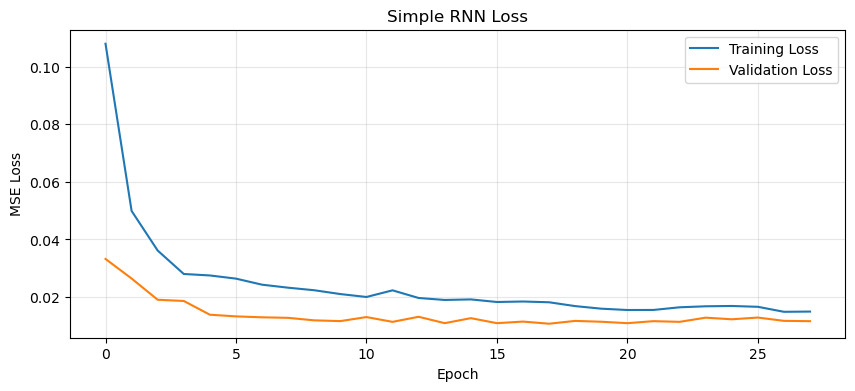

In [35]:
# RNN training aur validation loss plot kar rahe hain.

plt.figure(figsize=(10, 4))

plt.plot(rnn_history.history["loss"], label="Training Loss")

plt.plot(rnn_history.history["val_loss"], label="Validation Loss")

plt.title("Simple RNN Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


## RNN ki Limitations Isi Dataset par

### 1. Long Term Dependency

Dataset mein promotion ka delayed effect 14 din baad aur holiday ka effect 30 din baad aa sakta hai.  
Simple RNN recent information ko zyada importance de kar purani information bhool sakta hai.

### 2. Vanishing Gradient

30 time steps par backpropagation ke dauran gradients bohat chhotay ho sakte hain.  
Is wajah se sequence ke start ke days model ko kam influence karte hain.

### 3. Fixed Hidden State Pressure

Simple RNN ko bohat si information ek single hidden state mein compress karni hoti hai:

- visitors,
- promotion,
- holiday,
- temperature,
- past sales,
- seasonal pattern.

### 4. Unstable Long Sequence Learning

Sequence lambi karne par Simple RNN ka validation loss unstable ho sakta hai.

### 5. RNN ko LSTM/GRU se replace karna har problem ka magic solution nahi

LSTM aur GRU bhi:

- sequential models hain,
- training time lete hain,
- overfit kar sakte hain,
- aur achha data/preprocessing phir bhi zaroori hai.


# Part B LSTM se RNN Limitations Reduce Karna

LSTM mein:

- **Forget Gate** decide karta hai kya bhoolna hai.
- **Input Gate** decide karta hai kya nayi information store karni hai.
- **Cell State** long term memory carry karta hai.
- **Output Gate** decide karta hai kya output dena hai.

Is liye LSTM delayed effects aur long patterns ko Simple RNN se better learn kar sakta hai.


In [36]:
# LSTM model function define kar rahe hain.

def build_lstm_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        LSTM(

            units=32,

            activation="tanh"

        ),

        Dropout(0.20),

        Dense(

            units=16,

            activation="relu"

        ),

        Dense(

            units=1

        )

    ])


    model.compile(

        optimizer="adam",

        loss="mse",

        metrics=["mae"]

    )


    return model


In [37]:
# LSTM model create kar rahe hain.

lstm_model = build_lstm_model(

    input_shape=(X_train.shape[1], X_train.shape[2])

)


# Model architecture display kar rahe hain.

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           5,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# LSTM ke liye new EarlyStopping object bana rahe hain.

lstm_early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)


# LSTM train kar rahe hain.

lstm_history = lstm_model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.20,

    callbacks=[lstm_early_stopping],

    shuffle=False,

    verbose=1

)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.1007 - mae: 0.2550 - val_loss: 0.0270 - val_mae: 0.1292
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0389 - mae: 0.1572 - val_loss: 0.0248 - val_mae: 0.1207
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0336 - mae: 0.1357 - val_loss: 0.0229 - val_mae: 0.1183
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0304 - mae: 0.1378 - val_loss: 0.0219 - val_mae: 0.1177
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0292 - mae: 0.1304 - val_loss: 0.0216 - val_mae: 0.1157
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0274 - mae: 0.1286 - val_loss: 0.0207 - val_mae: 0.1142
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0260 - mae: 0.1243 - val_loss: 0.0201 - val_mae: 0.1125
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0267 - mae: 0.1272 - val_loss: 0.0198 - val_mae: 0.1110
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - lo

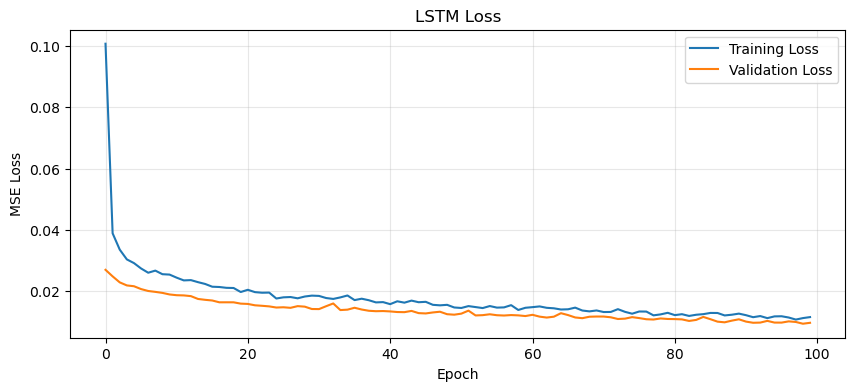

In [39]:
# LSTM training aur validation loss plot kar rahe hain.

plt.figure(figsize=(10, 4))

plt.plot(lstm_history.history["loss"], label="Training Loss")

plt.plot(lstm_history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# Part C GRU se RNN Limitations Reduce Karna

GRU bhi gated recurrent network hai.

GRU ke important gates:

- **Update Gate:** kitni old information retain karni hai.
- **Reset Gate:** kitni old information ignore karni hai.

GRU mein LSTM se gates kam hote hain, is liye:

- architecture simpler hoti hai,
- parameters aksar kam hote hain,
- training comparatively fast ho sakti hai.


In [40]:
# GRU model function define kar rahe hain.

def build_gru_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        GRU(

            units=32,

            activation="tanh"

        ),

        Dropout(0.20),

        Dense(

            units=16,

            activation="relu"

        ),

        Dense(

            units=1

        )

    ])


    model.compile(

        optimizer="adam",

        loss="mse",

        metrics=["mae"]

    )


    return model


In [41]:
# GRU model create kar rahe hain.

gru_model = build_gru_model(

    input_shape=(X_train.shape[1], X_train.shape[2])

)


# Model architecture display kar rahe hain.

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 32)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,769 (18.63 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# GRU ke liye new EarlyStopping object bana rahe hain.

gru_early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)


# GRU train kar rahe hain.

gru_history = gru_model.fit(

    X_train,

    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.20,

    callbacks=[gru_early_stopping],

    shuffle=False,

    verbose=1

)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0581 - mae: 0.1927 - val_loss: 0.0252 - val_mae: 0.1227
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0325 - mae: 0.1391 - val_loss: 0.0205 - val_mae: 0.1076
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0276 - mae: 0.1315 - val_loss: 0.0192 - val_mae: 0.1052
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0254 - mae: 0.1215 - val_loss: 0.0178 - val_mae: 0.1028
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0240 - mae: 0.1208 - val_loss: 0.0174 - val_mae: 0.1016
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0252 - mae: 0.1232 - val_loss: 0.0174 - val_mae: 0.1002
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0220 - mae: 0.1147 - val_loss: 0.0178 - val_mae: 0.1002
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0210 - mae: 0.1111 - val_loss: 0.0161 - val_mae: 0.0980
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - lo

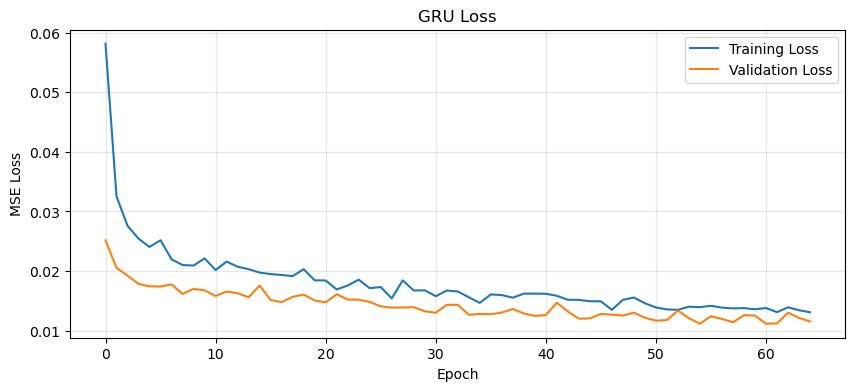

In [43]:
# GRU training aur validation loss plot kar rahe hain.

plt.figure(figsize=(10, 4))

plt.plot(gru_history.history["loss"], label="Training Loss")

plt.plot(gru_history.history["val_loss"], label="Validation Loss")

plt.title("GRU Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# Part D Fair Model Evaluation

Teenon models ko same test data par compare karenge:

- MAE
- RMSE
- R² Score
- Parameters
- Best validation loss


In [44]:
# Predictions ko original sales scale mein wapas lane ka function.

def inverse_sales_scale(scaled_values):

    return target_scaler.inverse_transform(scaled_values.reshape(-1, 1)).flatten()


# Actual sales ko original scale mein convert kar rahe hain.

actual_sales = inverse_sales_scale(y_test)


# RNN predictions.

rnn_predictions_scaled = rnn_model.predict(X_test, verbose=0)

rnn_predictions = inverse_sales_scale(rnn_predictions_scaled)


# LSTM predictions.

lstm_predictions_scaled = lstm_model.predict(X_test, verbose=0)

lstm_predictions = inverse_sales_scale(lstm_predictions_scaled)


# GRU predictions.

gru_predictions_scaled = gru_model.predict(X_test, verbose=0)

gru_predictions = inverse_sales_scale(gru_predictions_scaled)


In [45]:
# Metrics calculate karne ka reusable function.

def calculate_metrics(model_name, actual, predicted, model, history):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    r2 = r2_score(actual, predicted)

    parameters = model.count_params()

    best_validation_loss = min(history.history["val_loss"])


    return {

        "Model": model_name,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "Parameters": parameters,

        "Best_Validation_Loss": best_validation_loss

    }


In [46]:
# Teenon models ke results collect kar rahe hain.

results = []


results.append(

    calculate_metrics(

        "Simple RNN",

        actual_sales,

        rnn_predictions,

        rnn_model,

        rnn_history

    )

)


results.append(

    calculate_metrics(

        "LSTM",

        actual_sales,

        lstm_predictions,

        lstm_model,

        lstm_history

    )

)


results.append(

    calculate_metrics(

        "GRU",

        actual_sales,

        gru_predictions,

        gru_model,

        gru_history

    )

)


# Comparison DataFrame create kar rahe hain.

results_df = pd.DataFrame(results)


# RMSE ke mutabiq best se worst order mein sort kar rahe hain.

results_df = results_df.sort_values("RMSE").reset_index(drop=True)


results_df.round(4)


,Model,MAE,RMSE,R2,Parameters,Best_Validation_Loss
0,LSTM,1120.5755,1487.0175,0.6121,6049,0.0094
1,GRU,1141.4051,1546.1206,0.5807,4769,0.0112
2,Simple RNN,1250.3311,1645.5200,0.5250,1921,0.0107


In [47]:
# Best model automatically identify kar rahe hain.

best_model_name = results_df.loc[0, "Model"]


print("Test RMSE ke mutabiq Best Model:", best_model_name)


Test RMSE ke mutabiq Best Model: LSTM


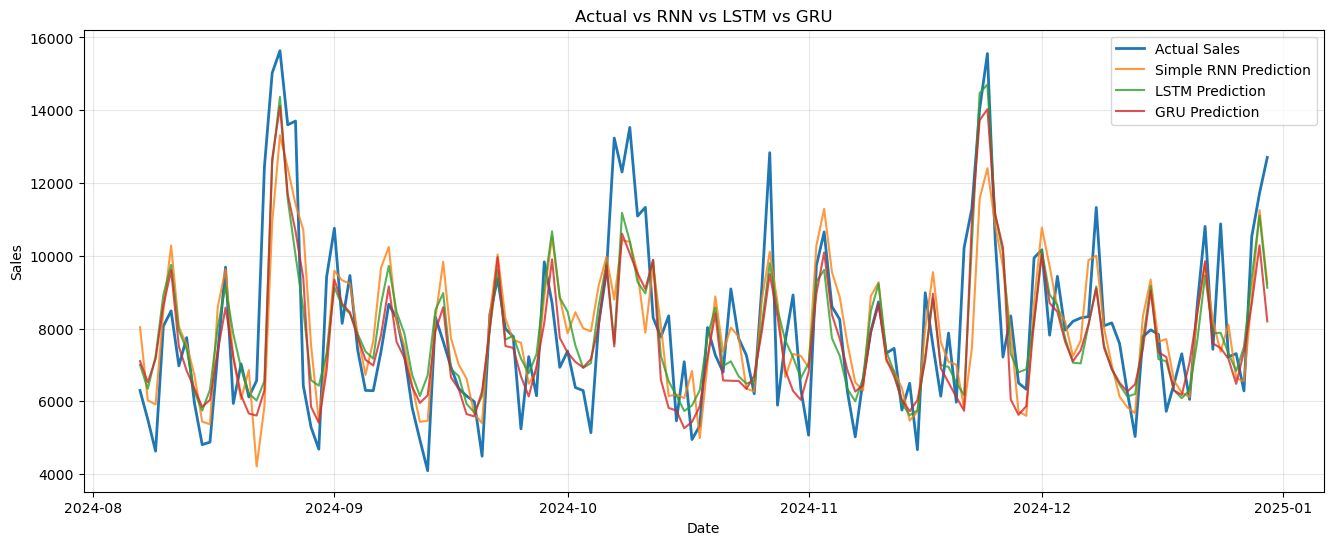

In [48]:
# Actual aur predicted sales ka comparison graph.

plt.figure(figsize=(16, 6))

plt.plot(test_dates, actual_sales, label="Actual Sales", linewidth=2)

plt.plot(test_dates, rnn_predictions, label="Simple RNN Prediction", alpha=0.8)

plt.plot(test_dates, lstm_predictions, label="LSTM Prediction", alpha=0.8)

plt.plot(test_dates, gru_predictions, label="GRU Prediction", alpha=0.8)

plt.title("Actual vs RNN vs LSTM vs GRU")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


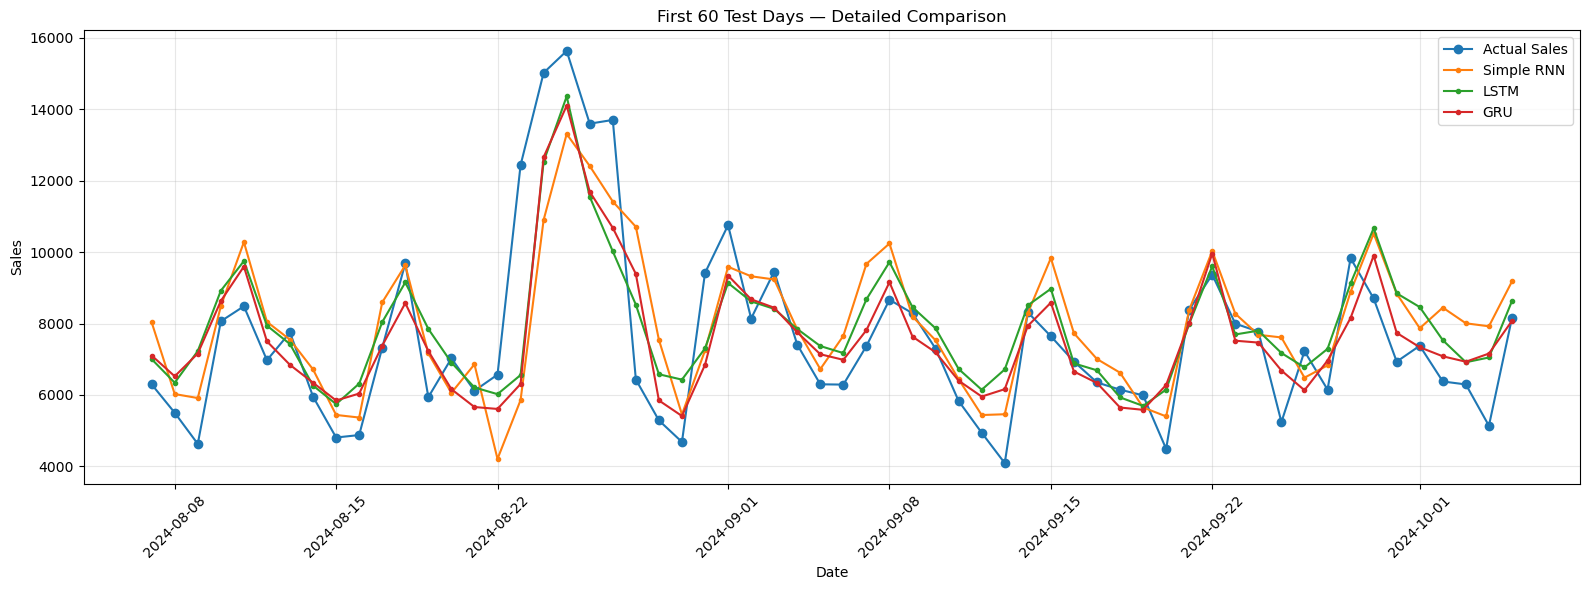

In [49]:
# Sirf first 60 test days ko zoom karke compare kar rahe hain.

display_days = 60


plt.figure(figsize=(16, 6))

plt.plot(

    test_dates.iloc[:display_days],

    actual_sales[:display_days],

    marker="o",

    label="Actual Sales"

)

plt.plot(

    test_dates.iloc[:display_days],

    rnn_predictions[:display_days],

    marker=".",

    label="Simple RNN"

)

plt.plot(

    test_dates.iloc[:display_days],

    lstm_predictions[:display_days],

    marker=".",

    label="LSTM"

)

plt.plot(

    test_dates.iloc[:display_days],

    gru_predictions[:display_days],

    marker=".",

    label="GRU"

)

plt.title("First 60 Test Days — Detailed Comparison")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


## Results:

- **Lower MAE better hai.**
- **Lower RMSE better hai.**
- **Higher R² better hai.**
- Parameters model complexity ko show karte hain.
- Sirf training loss dekh kar best model decide nahi karna.
- Final decision unseen test data ke metrics par hona chahiye.

Expected teaching observation:

- Simple RNN long dependency ko miss kar sakta hai.
- LSTM long term memory ki wajah se improve kar sakta hai.
- GRU LSTM jaisi gating ke sath fewer parameters mein strong result de sakta hai.
- Actual winner run-to-run aur data ke mutabiq change ho sakta hai.


# Part E Next Day Forecast

Best model ko automatically select karke next day ki Sales predict karenge.


In [50]:
# Model name ke basis par trained model select kar rahe hain.

trained_models = {

    "Simple RNN": rnn_model,

    "LSTM": lstm_model,

    "GRU": gru_model

}


best_model = trained_models[best_model_name]


# Dataset ke last 30 days features le rahe hain.

last_sequence = scaled_features[-TIME_STEPS:]


# Keras ke required 3D format mein reshape kar rahe hain.

last_sequence = last_sequence.reshape(

    1,

    TIME_STEPS,

    len(feature_columns)

)


# Next day ki scaled prediction kar rahe hain.

next_day_scaled_prediction = best_model.predict(

    last_sequence,

    verbose=0

)


# Prediction ko original Sales scale mein convert kar rahe hain.

next_day_sales_prediction = target_scaler.inverse_transform(

    next_day_scaled_prediction

)[0][0]


# Next date calculate kar rahe hain.

next_date = data["Date"].max() + pd.Timedelta(days=1)


print("Selected Best Model:", best_model_name)

print("Forecast Date:", next_date.date())

print("Predicted Sales:", round(float(next_day_sales_prediction), 2))


Selected Best Model: LSTM
Forecast Date: 2024-12-31
Predicted Sales: 8959.71


# Practice Tasks 

1. `TIME_STEPS = 7`, `14`, `30`, aur `60` karke metrics compare karein.  
2. `units=32` ko `64` karke result compare karein.  
3. `Dropout(0.20)` hata kar overfitting observe karein.  
4. `Sales` ko input features se remove karke performance compare karein.  
5. Sirf univariate `Sales` series par RNN, LSTM aur GRU run karein.  
6. Best model ka residual/error graph banayein.  
